In [2]:
from feature_module import *

In [3]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

In [4]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")

print(DK1_train.head())

Notebook_dir: c:\Users\chris\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\chris\Documents\Python\Speciale_Kode
Data_folder: c:\Users\chris\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
      DKPrice                Time  OffshoreWindPower  OnshoreWindPower  \
0   73.860001 2016-01-02 00:00:00         629.136470        675.652371   
1  112.139999 2016-01-02 01:00:00         695.229495       1010.091448   
2   95.279999 2016-01-02 02:00:00         726.687097       1397.652714   
3   84.089996 2016-01-02 03:00:00         740.683298       1666.008909   
4   88.860001 2016-01-02 04:00:00         657.776666       1842.673544   

   HydroPower  SolarPower     Biomass     Biogas      Waste   FossilGas  ...  \
0    2.043175    0.048376  100.664682  43.830806  87.288793   99.595932  ... 

In [5]:
y_DK1_train = DK1_train[["DKPrice"]].copy()

X_DK1_train = DK1_train.drop("DKPrice", axis = 1)
X_DK1_train = X_DK1_train.drop("Time", axis = 1)

y_DK2_train = DK2_train[["DKPrice"]].copy()

X_DK2_train = DK2_train.drop("DKPrice", axis = 1)
X_DK2_train = X_DK2_train.drop("Time", axis = 1)

Running feature selectors …
  [1/5] Mutual information … done
  [2/5] Lasso / ElasticNet … done
  [3/5] Random Forest MDI … done
  [4/5] Permutation importance … done
  [5/5] SHAP (LightGBM TreeExplainer) … done
  [6/6] RFECV (Lasso estimator, TimeSeriesSplit) … done

Done. Top 15 features by consensus rank:
                      mean_rank  consensus_score
DEPrice                2.071429         0.147758
Price_lag1             2.214286         0.138225
NO2Price               3.642857         0.084019
NLPrice                4.357143         0.070246
SE4Price               4.500000         0.068016
Price_lag24            8.357143         0.036624
SolarPowerCapacity    13.571429         0.022553
SE3Price              13.857143         0.022088
ExchangeNorway        13.857143         0.022088
OffshoreWindPower     15.000000         0.020405
WindSpeed             15.857143         0.019302
Year                  17.000000         0.018004
OffshoreWindCapacity  17.142857         0.017854
Gros

c:\Users\chris\Documents\Python\Speciale_Kode\Feature_selector\feature_module.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


Plot saved to feature_selector_comparison_DK1.png


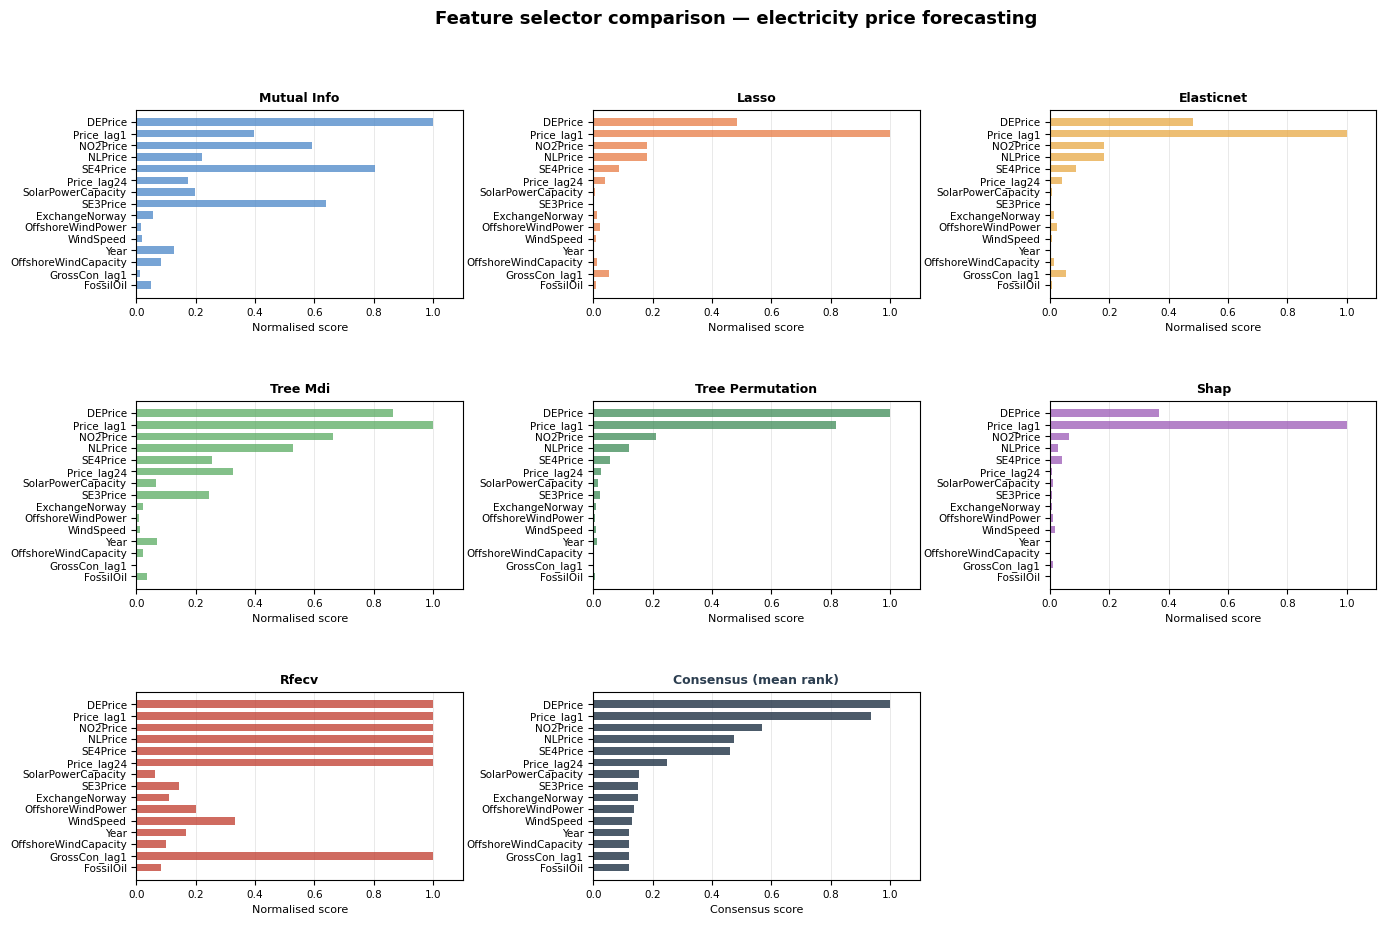

In [6]:
suite_DK1 = FeatureSelectorSuite(
    X_train = X_DK1_train,
    y_train = y_DK1_train,
    n_top = 15,
    n_cv_splits = 5,
    run_rfe = True,
    random_state = 42
)

results_DK1 = suite_DK1.run_all()
print("\nFull rank table:")
print(results_DK1.to_string())

consensus_DK1 = suite_DK1.consensus_features(top_k=15)
print(f"\nConsensus top-15 features:\n{consensus_DK1}")
suite_DK1.plot_comparison(save_path = "feature_selector_comparison_DK1.png")

Running feature selectors …
  [1/5] Mutual information … done
  [2/5] Lasso / ElasticNet … done
  [3/5] Random Forest MDI … done
  [4/5] Permutation importance … done
  [5/5] SHAP (LightGBM TreeExplainer) … done
  [6/6] RFECV (Lasso estimator, TimeSeriesSplit) … done

Done. Top 15 features by consensus rank:
                    mean_rank  consensus_score
Price_lag1           1.571429         0.187155
DEPrice              2.142857         0.137247
SE4Price             4.000000         0.073525
NLPrice              4.285714         0.068624
NO2Price             5.285714         0.055641
Price_lag24          9.000000         0.032678
SolarPowerCapacity  13.285714         0.022137
OffshoreWindPower   13.857143         0.021224
WindSpeed           13.857143         0.021224
Year                14.000000         0.021007
SE3Price            14.000000         0.021007
SolarPower          14.857143         0.019795
ExchangeGreatBelt   16.142857         0.018219
GrossCon_lag1       17.142857   

c:\Users\chris\Documents\Python\Speciale_Kode\Feature_selector\feature_module.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


Plot saved to feature_selector_comparison_DK2.png


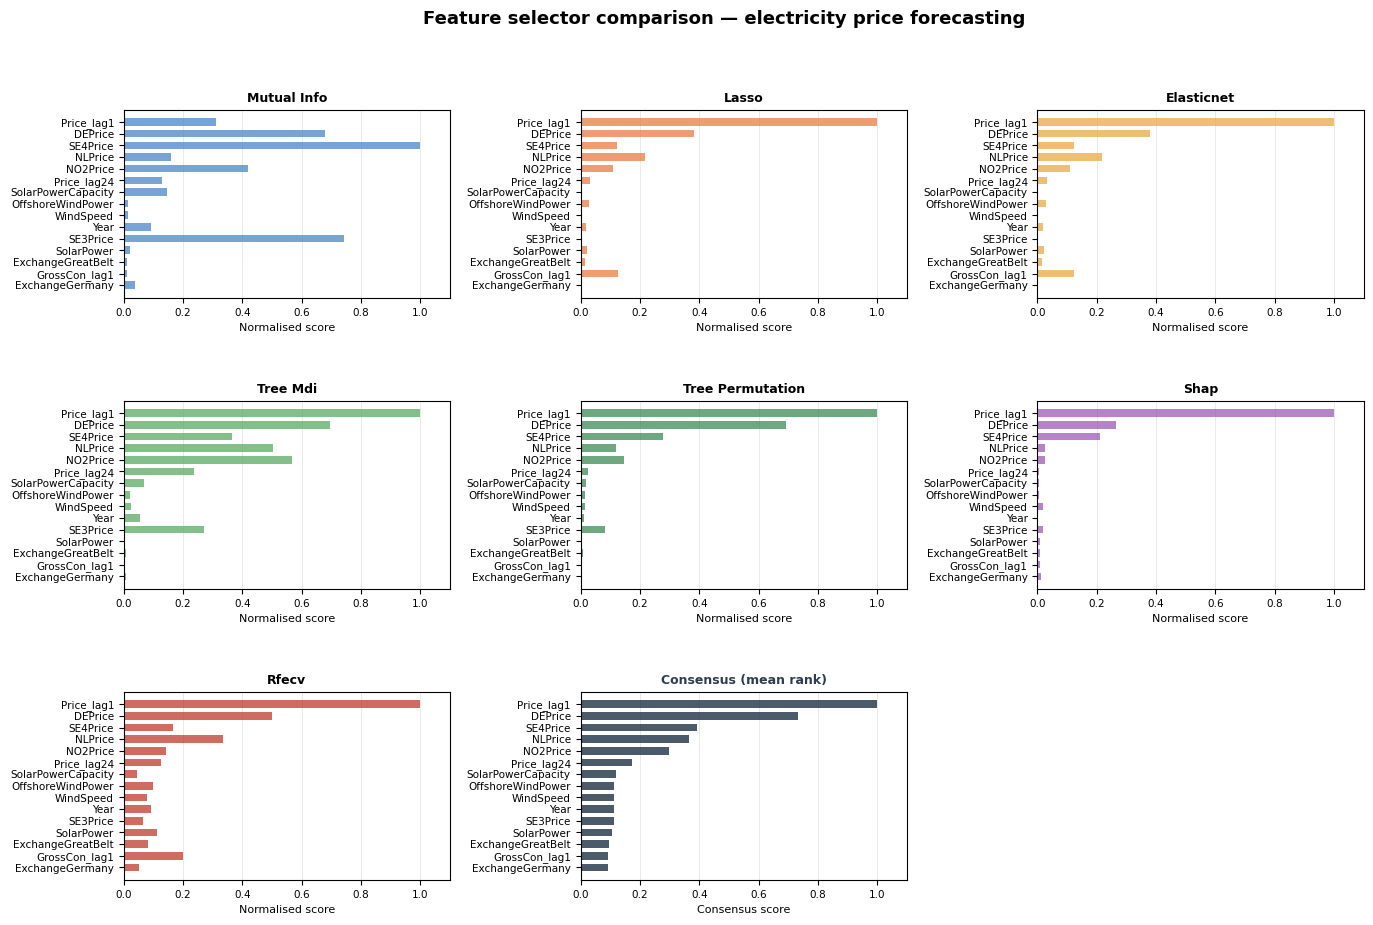

In [7]:
suite_DK2 = FeatureSelectorSuite(
    X_train = X_DK2_train,
    y_train = y_DK2_train,
    n_top = 15,
    n_cv_splits = 5,
    run_rfe = True,
    random_state = 42
)

results_DK2 = suite_DK2.run_all()
print("\nFull rank table:")
print(results_DK2.to_string())

consensus_DK2 = suite_DK2.consensus_features(top_k=15)
print(f"\nConsensus top-15 features:\n{consensus_DK2}")
suite_DK2.plot_comparison(save_path = "feature_selector_comparison_DK2.png")